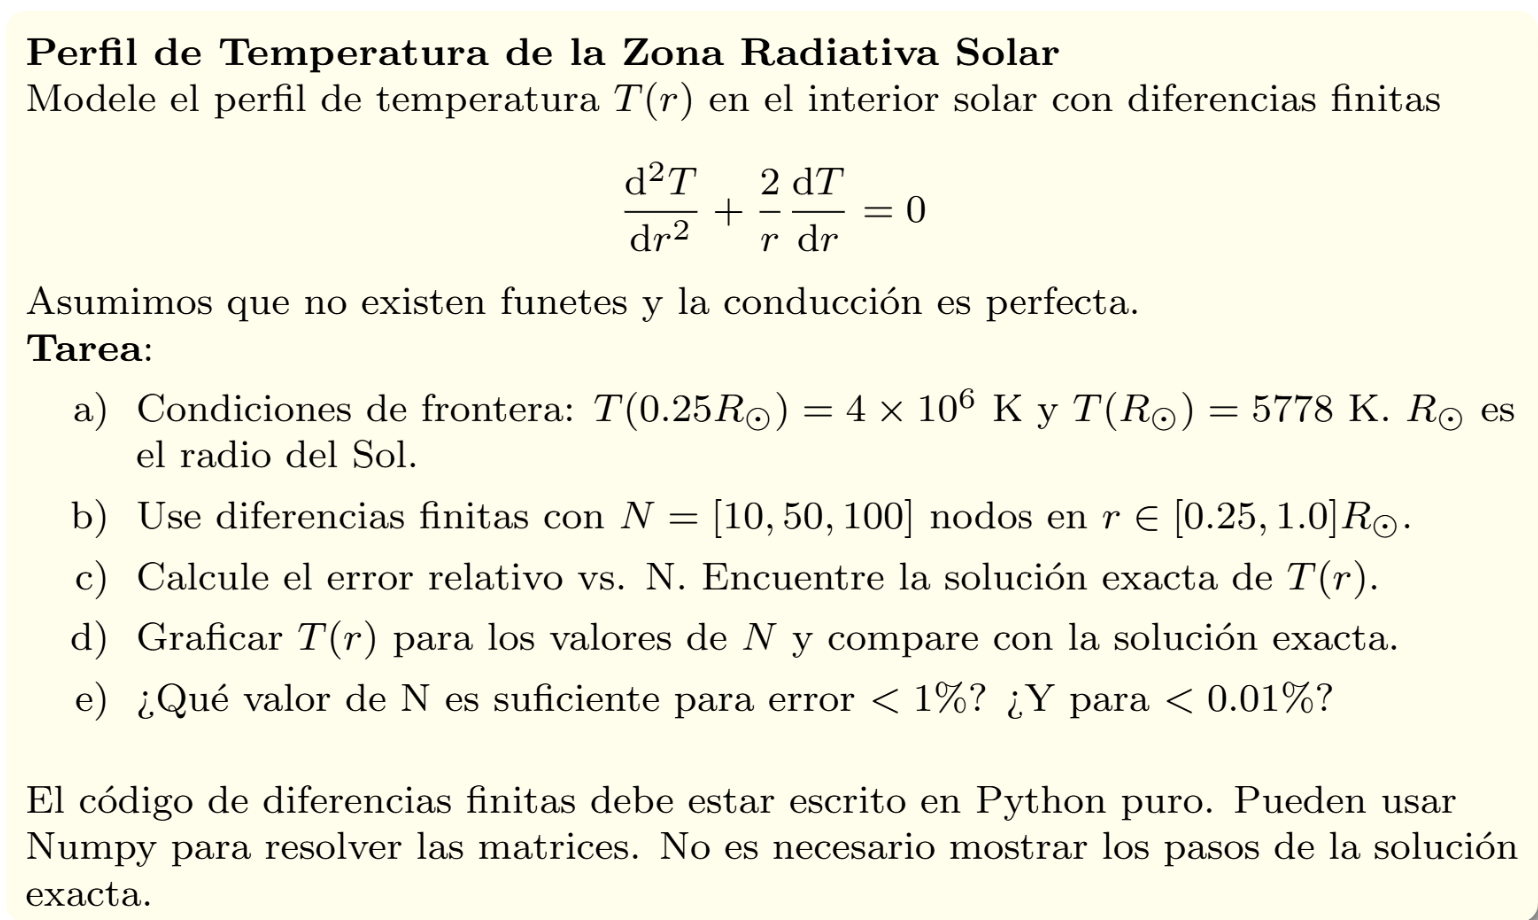

PUNTO C) SOLUCION ANALITICA EXACTA
C1 = 1331407.3333333333
C2 = -1325629.3333333333
Ecuacion exacta: T(r) = 1331407.3333333333 / r + -1325629.3333333333
PUNTOS B Y C) RESOLUCION POR DIFERENCIAS FINITAS Y ERROR
N = 10 | Error Relativo % = 2.0728209626543542e-14
N = 50 | Error Relativo % = 3.543784289631697e-13
N = 100 | Error Relativo % = 3.8623322498113873e-13


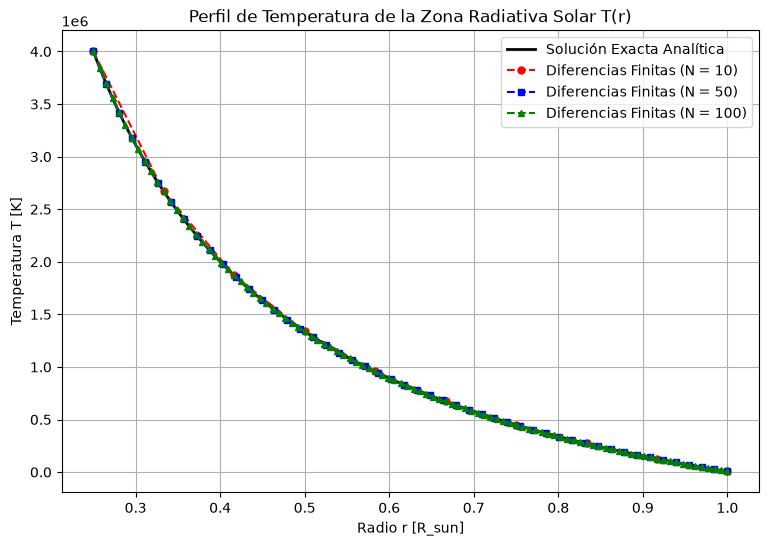

PUNTO E) EVALUACION DE N PARA UMBRALES DE ERROR
Valor minimo de N para un error < 1.0%   : N = 3
Valor minimo de N para un error < 0.01%  : N = 3


In [3]:
import numpy as np
import matplotlib.pyplot as plt

#  a) Condiciones de frontera y constantes fisicas
r_a = 0.25
r_b = 1
T_a = 4.0e6
T_b = 5778


# c) Solucion analitica
C1 = (T_a - T_b) / ((1.0 / r_a) - (1.0 / r_b))
C2 = T_b - (C1 / r_b)

print("PUNTO C) SOLUCION ANALITICA EXACTA")
print("C1 =", C1)
print("C2 =", C2)
print("Ecuacion exacta: T(r) =", C1, "/ r +", C2)


# b) Lista de nodos
lista_N = [10, 50, 100]

soluciones_r = []
soluciones_T = []
errores_relativos = []

print("PUNTOS B Y C) RESOLUCION POR DIFERENCIAS FINITAS Y ERROR")

for N in lista_N:
    r = np.linspace(r_a, r_b, N)
    dr = (r_b - r_a) / (N - 1)
    
    T = np.zeros(N)
    
    A = np.zeros((N, N))
    B = np.zeros(N)
    
    # Condicion de frontera izquierda (nodo i = 0)
    A[0, 0] = 1.0
    B[0] = T_a
    
    # Condicion de frontera derecha (nodo i = N - 1)
    A[N - 1, N - 1] = 1.0
    B[N - 1] = T_b
    
    # Llenado de nodos interiores
    for i in range(1, N - 1):
        r_i = r[i]
        coef_izq = 1.0 - (dr / r_i)
        coef_cen = -2.0
        coef_der = 1.0 + (dr / r_i)
        
        A[i, i - 1] = coef_izq
        A[i, i] = coef_cen
        A[i, i + 1] = coef_der
        B[i] = 0.0

    # Eliminacion Gaussiana con Pivoteo Parcial
    M = np.hstack([A.copy(), B.copy().reshape(-1, 1)])
    
    # Eliminacion hacia adelante
    for k in range(N):
        # Busqueda del pivote maximo
        max_index = k + np.argmax(np.abs(M[k:, k]))
        if max_index != k:
            M[[k, max_index]] = M[[max_index, k]]
            
        # Anular elementos por debajo de la diagonal
        for i_row in range(k + 1, N):
            factor = M[i_row, k] / M[k, k]
            M[i_row, k:] = M[i_row, k:] - factor * M[k, k:]

    # Sustitucion hacia atras
    for i_row in range(N - 1, -1, -1):
        suma = np.dot(M[i_row, i_row + 1:N], T[i_row + 1:N])
        T[i_row] = (M[i_row, N] - suma) / M[i_row, i_row]
        
    # Calculo de la solucion exacta en los nodos de la malla
    T_exacta_nodos = (C1 / r) + C2
    
    # Error relativo L2
    error_relativo = (np.linalg.norm(T - T_exacta_nodos) / np.linalg.norm(T_exacta_nodos)) * 100.0
    
    # Almacenar soluciones para graficar
    soluciones_r.append(r)
    soluciones_T.append(T)
    errores_relativos.append(error_relativo)
    
    print("N =", N, "| Error Relativo % =", error_relativo)


# PUNTO d) Grafica y comparar con la solucion exacta
plt.figure(figsize=(9, 6))

# Curva de la solucion
r_fino = np.linspace(r_a, r_b, 500)
T_exacta_fina = (C1 / r_fino) + C2
plt.plot(r_fino, T_exacta_fina, 'k-', linewidth=2.0, label='Solución Exacta Analítica')

# Graficar cada N
estilos = ['ro--', 'bs--', 'g^--']
for i in range(len(lista_N)):
    plt.plot(soluciones_r[i], soluciones_T[i], estilos[i], markersize=5, label=f'Diferencias Finitas (N = {lista_N[i]})')

plt.xlabel('Radio r [R_sun]')
plt.ylabel('Temperatura T [K]')
plt.title('Perfil de Temperatura de la Zona Radiativa Solar T(r)')
plt.legend()
plt.grid(True)
plt.show()

# Punto e)
print("PUNTO E) EVALUACION DE N PARA UMBRALES DE ERROR")

N_eval = 3
N_para_1_porciento = None
N_para_001_porciento = None

while N_eval <= 1000:
    r_ev = np.linspace(r_a, r_b, N_eval)
    dr_ev = (r_b - r_a) / (N_eval - 1)
    
    A_ev = np.zeros((N_eval, N_eval))
    B_ev = np.zeros(N_eval)
    
    A_ev[0, 0] = 1.0
    B_ev[0] = T_a
    A_ev[N_eval - 1, N_eval - 1] = 1.0
    B_ev[N_eval - 1] = T_b
    
    for i in range(1, N_eval - 1):
        r_i = r_ev[i]
        A_ev[i, i - 1] = 1.0 - (dr_ev / r_i)
        A_ev[i, i] = -2.0
        A_ev[i, i + 1] = 1.0 + (dr_ev / r_i)
        B_ev[i] = 0.0

    # Eliminacion Gaussiana con Pivoteo Parcial
    M_ev = np.hstack([A_ev.copy(), B_ev.copy().reshape(-1, 1)])
    T_ev = np.zeros(N_eval)
    
    for k in range(N_eval):
        max_idx = k + np.argmax(np.abs(M_ev[k:, k]))
        if max_idx != k:
            M_ev[[k, max_idx]] = M_ev[[max_idx, k]]
        for i_row in range(k + 1, N_eval):
            fact = M_ev[i_row, k] / M_ev[k, k]
            M_ev[i_row, k:] = M_ev[i_row, k:] - fact * M_ev[k, k:]

    for i_row in range(N_eval - 1, -1, -1):
        sm = np.dot(M_ev[i_row, i_row + 1:N_eval], T_ev[i_row + 1:N_eval])
        T_ev[i_row] = (M_ev[i_row, N_eval] - sm) / M_ev[i_row, i_row]

    T_ex = (C1 / r_ev) + C2
    err = (np.linalg.norm(T_ev - T_ex) / np.linalg.norm(T_ex)) * 100.0
    
    if N_para_1_porciento is None and err < 1.0:
        N_para_1_porciento = N_eval
        
    if N_para_001_porciento is None and err < 0.01:
        N_para_001_porciento = N_eval
        break
        
    N_eval = N_eval + 1

print("Valor minimo de N para un error < 1.0%   : N =", N_para_1_porciento)
print("Valor minimo de N para un error < 0.01%  : N =", N_para_001_porciento)